In [ ]:
import os
os.environ["KAGGLE"] = "/content/drive/MyDrive/kaggle.json"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import shutil

# Create the destination directory if it doesn't exist
os.makedirs("/root/.kaggle/", exist_ok=True)

# Now move the file
shutil.move("/content/drive/MyDrive/kaggle.json", "/root/.kaggle/")

'/root/.kaggle/kaggle.json'

In [ ]:
#!/bin/bash
!kaggle datasets download msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0


In [ ]:
!unzip fer2013.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/sad/Training_65242339.jpg  
  inflating: train/sad/Training_65267116.jpg  
  inflating: train/sad/Training_65275626.jpg  
  inflating: train/sad/Training_6529266.jpg  
  inflating: train/sad/Training_65329617.jpg  
  inflating: train/sad/Training_65338712.jpg  
  inflating: train/sad/Training_65338797.jpg  
  inflating: train/sad/Training_65387162.jpg  
  inflating: train/sad/Training_65404494.jpg  
  inflating: train/sad/Training_65426218.jpg  
  inflating: train/sad/Training_65430136.jpg  
  inflating: train/sad/Training_65437377.jpg  
  inflating: train/sad/Training_6545735.jpg  
  inflating: train/sad/Training_65463385.jpg  
  inflating: train/sad/Training_65473985.jpg  
  inflating: train/sad/Training_65502829.jpg  
  inflating: train/sad/Training_65505359.jpg  
  inflating: train/sad/Training_65508578.jpg  
  inflating: train/sad/Training_65516023.jpg  
  inflating: train/sad/Training_65524027.jpg  
  inflating

In [ ]:
!pip install tensorflow
!pip install keras

In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D
from keras.optimizers import Adam
from keras.layers import MaxPooling2D
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import cv2
import matplotlib.pyplot as plt

(48, 48, 3)

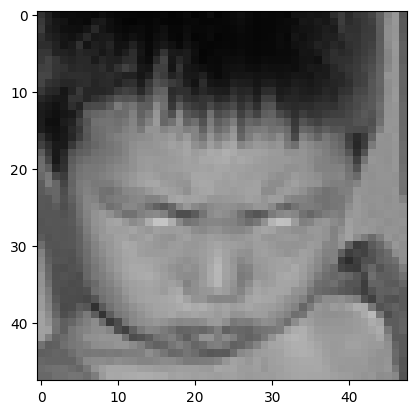

In [ ]:
img = image.load_img("/content/train/angry/Training_10118481.jpg")

plt.imshow(img)
cv2.imread("/content/train/angry/Training_10118481.jpg").shape

In [ ]:
train = ImageDataGenerator(rescale=1./255)
test = ImageDataGenerator(rescale=1./255)

training_dataset = train.flow_from_directory("/content/train",
                                            target_size=(48,48),
                                            batch_size=64,
                                            color_mode="grayscale",
                                            class_mode="categorical")

testing_dataset = test.flow_from_directory("/content/test",
                                            target_size=(48,48),
                                            batch_size=64,
                                            color_mode="grayscale",
                                            class_mode="categorical")


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
training_dataset.class_indices
testing_dataset.class_indices

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

In [ ]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(48,48,1)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(7, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Import necessary modules
from keras.optimizers import Adam
from keras.optimizers.schedules import ExponentialDecay
from keras import metrics

# Define learning rate schedule
initial_learning_rate = 0.0001
lr_schedule = ExponentialDecay(
    initial_learning_rate,
    decay_steps=10000,  # Adjust as needed
    decay_rate=0.96,    # Adjust as needed
    staircase=True
)

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=lr_schedule),  # Use learning_rate argument here
    metrics=['accuracy' , metrics.Precision(), metrics.Recall()]
)


In [ ]:
model_info = model.fit(
    training_dataset,
    steps_per_epoch=28709 // 64,
    epochs=50,
    validation_data=testing_dataset,
    validation_steps=7178 // 64
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


448/448 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.2489 - loss: 1.8324 - precision: 0.0515 - recall: 1.2340e-05 - val_accuracy: 0.3064 - val_loss: 1.7203 - val_precision: 0.6136 - val_recall: 0.0038
Epoch 2/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.1406 - loss: 1.8735 - precision: 0.6667 - recall: 0.0312

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1406 - loss: 1.8735 - precision: 0.6667 - recall: 0.0312 - val_accuracy: 0.3036 - val_loss: 1.7196 - val_precision: 0.6071 - val_recall: 0.0047
Epoch 3/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.3352 - loss: 1.6779 - precision: 0.6526 - recall: 0.0467 - val_accuracy: 0.4169 - val_loss: 1.5256 - val_precision: 0.7656 - val_recall: 0.1281
Epoch 4/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3594 - loss: 1.6795 - precision: 0.7000 - recall: 0.1094 - val_accuracy: 0.4162 - val_loss: 1.5257 - val_precision: 0.7588 - val_recall: 0.1321
Epoch 5/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.4055 - loss: 1.5448 - precision: 0.7245 - recall: 0.1416 - val_accuracy: 0.4417 - val_loss: 1.4543 - val_precision: 0.7485 - val_recall: 0.1735
Epoch 6/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5156 - loss: 1.2695 - precision: 0.7619 - recall: 0.2500 - val_accuracy: 0.4396 - val_loss: 1.4588 - 

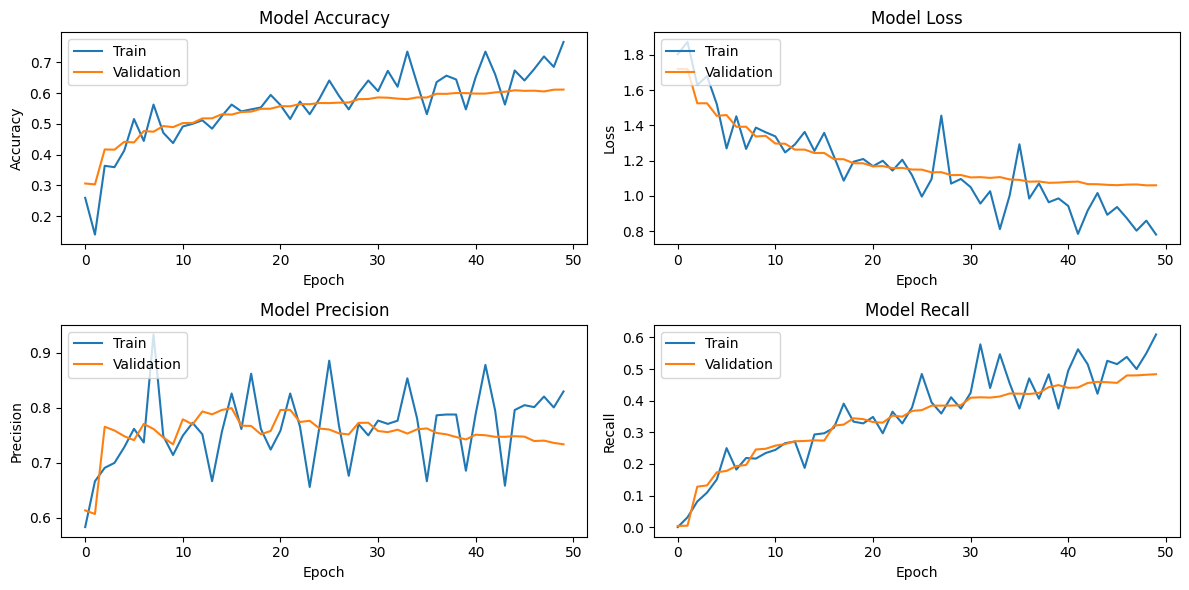

In [ ]:
# Import necessary modules
from keras.optimizers import Adam
from keras.optimizers.schedules import ExponentialDecay
from keras import metrics
import matplotlib.pyplot as plt

# ... (Your existing code for model compilation and training) ...

# Plot the graphs in a 2x2 matrix
fig, axs = plt.subplots(2, 2, figsize=(12, 6))

# Accuracy
axs[0, 0].plot(model_info.history['accuracy'])
axs[0, 0].plot(model_info.history['val_accuracy'])
axs[0, 0].set_title('Model Accuracy')
axs[0, 0].set_ylabel('Accuracy')
axs[0, 0].set_xlabel('Epoch')
axs[0, 0].legend(['Train', 'Validation'], loc='upper left')

# Loss
axs[0, 1].plot(model_info.history['loss'])
axs[0, 1].plot(model_info.history['val_loss'])
axs[0, 1].set_title('Model Loss')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].set_xlabel('Epoch')
axs[0, 1].legend(['Train', 'Validation'], loc='upper left')

# Precision
axs[1, 0].plot(model_info.history['precision'])  # Or model_info.history['precision_1'] if using multiple metrics
axs[1, 0].plot(model_info.history['val_precision'])  # Or model_info.history['val_precision_1']
axs[1, 0].set_title('Model Precision')
axs[1, 0].set_ylabel('Precision')
axs[1, 0].set_xlabel('Epoch')
axs[1, 0].legend(['Train', 'Validation'], loc='upper left')

# Recall
axs[1, 1].plot(model_info.history['recall'])  # Or model_info.history['recall_1'] if using multiple metrics
axs[1, 1].plot(model_info.history['val_recall'])  # Or model_info.history['val_recall_1']
axs[1, 1].set_title('Model Recall')
axs[1, 1].set_ylabel('Recall')
axs[1, 1].set_xlabel('Epoch')
axs[1, 1].legend(['Train', 'Validation'], loc='upper left')


plt.tight_layout()  # Adjust layout for better spacing
plt.show()

In [59]:
from sklearn.metrics import f1_score
# Assuming you have your testing data in 'testing_dataset'
y_true = testing_dataset.classes  # True labels
y_pred = model.predict(testing_dataset)  # Predictions from your model
y_pred = np.argmax(y_pred, axis=1)  # Convert predictions to class labels
f1 = f1_score(y_true, y_pred, average='weighted')  # Use 'weighted' for multi-class
print(f"F1 Score: {f1}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step
F1 Score: 0.17364336184033244


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import img_to_array
from PIL import Image # Import the Image module

image_path = "/content/test/sad/PrivateTest_10247676.jpg"

img = Image.open(image_path).convert('L') # Open image and convert to grayscale
img = img.resize((48, 48))  # Resize to match the input your model expects
x = img_to_array(img)
x=np.expand_dims(x,axis=0)
x=np.expand_dims(x,axis=-1)
images = np.vstack([x])
val = model.predict(images)
if val[0][0] == 1:
    print("Angry")

elif val[0][1] == 1:
    print("disgust")

elif val[0][2] == 1:
    print("fear")

elif val[0][3] == 1:
    print("happy")

elif val[0][4] == 1:
    print("neutral")

elif val[0][5] == 1:
    print("sad")

elif val[0][6] == 1:
    print("surprise")

else:
  print("none")



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
fear


In [ ]:
model.save("/content/drive/MyDrive/mymodel.keras")

# **TESTING**


In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model("/content/drive/MyDrive/mymodel.keras")  # Replace "model.h5" with your actual model filename


In [58]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import img_to_array
from PIL import Image # Import the Image module

image_path = "/content/drive/MyDrive/happy1.png"

img = Image.open(image_path).convert('L') # Open image and convert to grayscale
img = img.resize((48, 48))  # Resize to match the input your model expects
x = img_to_array(img)
x=np.expand_dims(x,axis=0)
x=np.expand_dims(x,axis=-1)
images = np.vstack([x])
val = model.predict(images)
if val[0][0] == 1:
    print("Angry")

elif val[0][1] == 1:
    print("disgust")

elif val[0][2] == 1:
    print("fear")

elif val[0][3] == 1:
    print("happy")

elif val[0][4] == 1:
    print("neutral")

elif val[0][5] == 1:
    print("sad")

elif val[0][6] == 1:
    print("surprise")

else:
  print("none")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
happy
